### 고객 군집분류

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [1]:
%cd /content/drive/MyDrive/대학원/202303자료/2.AI응용/팀플/AI응용_팀플_Lpoint

/content/drive/.shortcut-targets-by-id/14njhqlSBFDonO-JQpFF9BKU1XLIyCT_5/AI응용_팀플_Lpoint


In [4]:
# 데이터 로드
df = pd.read_csv('./fin_data_set.csv')
df1 = pd.read_csv('./final_data.csv')
df1.head(2)

,cno,gender,age_grp,scls_c_nm,Recency,Frequency,Monetory
0,1,M,60세이상,Bag&Bag,135,1,186200
1,1,M,60세이상,L.B,277,1,85500


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11862 entries, 0 to 11861
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer        11862 non-null  int64  
 1   Recency         11862 non-null  float64
 2   Frequency       11862 non-null  int64  
 3   Monetory        11862 non-null  int64  
 4   Purchase_Cycle  11862 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 463.5 KB


In [9]:
df = df.rename({'customer':'cno'}, axis=1)

In [6]:
data1 = df1[['cno','gender','age_grp']].drop_duplicates().reset_index(drop=True)
data1.head()

,cno,gender,age_grp
0,1,M,60세이상
1,2,M,60세이상
2,4,F,60세이상
3,5,M,60세이상
4,6,F,60세이상


In [10]:
cust1 = data1.merge(df, on='cno')
cust1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11862 entries, 0 to 11861
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cno             11862 non-null  int64  
 1   gender          11862 non-null  object 
 2   age_grp         11862 non-null  object 
 3   Recency         11862 non-null  float64
 4   Frequency       11862 non-null  int64  
 5   Monetory        11862 non-null  int64  
 6   Purchase_Cycle  11862 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 741.4+ KB


In [18]:
cust1.head(2)

,cno,gender,age_grp,Recency,Frequency,Monetory,Purchase_Cycle
0,1,M,60세이상,11.0,322,35834150,3.76
1,2,M,60세이상,3.0,319,51600290,2.78


In [27]:
# 성별, 나이 라벨인코딩
data = label_at(cust1, ['gender_le','age_grp'])

#### 성별, 나이

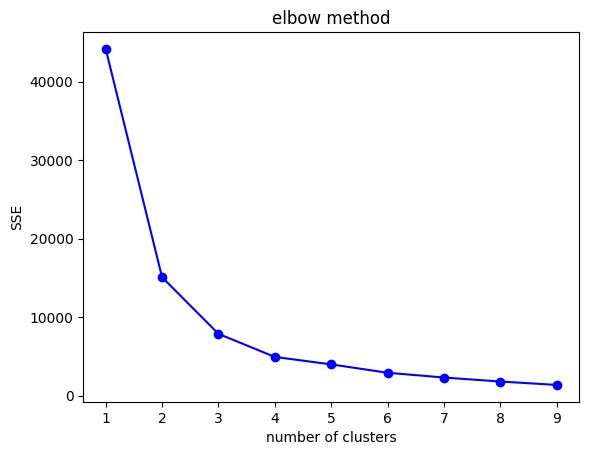

In [ ]:
# 성별과 나이로만 군집분류
X1 = data[['gender_le', 'age_grp_le']]
elbow(X1, 10) # 1에 가까울 수록 근처 군집과 멀리 떨어져 있음

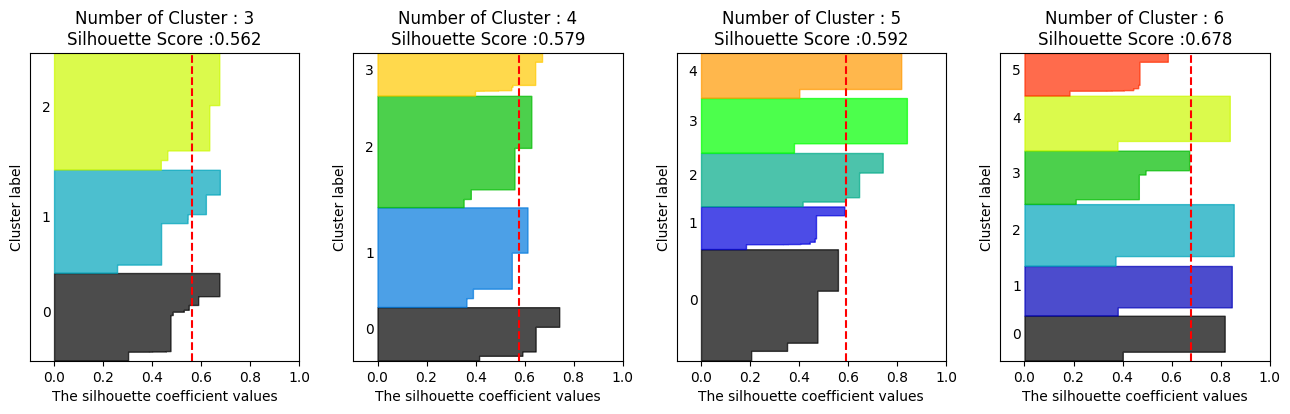

In [ ]:
visualize_silhouette([3, 4, 5,6], X1)

In [ ]:
X_data, model = cluster_kmeans(X1, 6)

5    2386
2    2117
1    2061
3    1918
4    1733
0    1647
Name: cluster, dtype: int64


#### 다른컬럼 추가이용

##### 구매빈도 추가

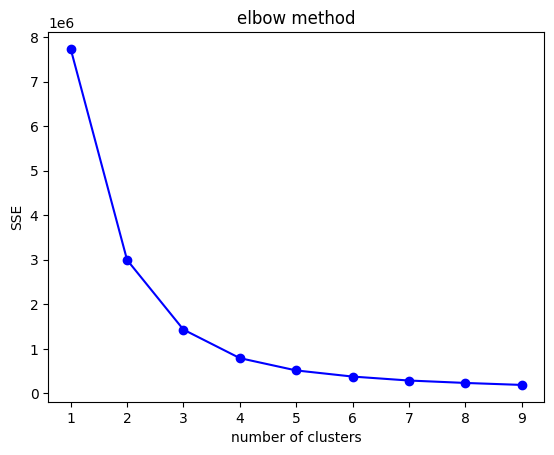

In [32]:
X = data[['Purchase_Cycle',
       'gender_le', 'age_grp_le']]

elbow(X, 10)

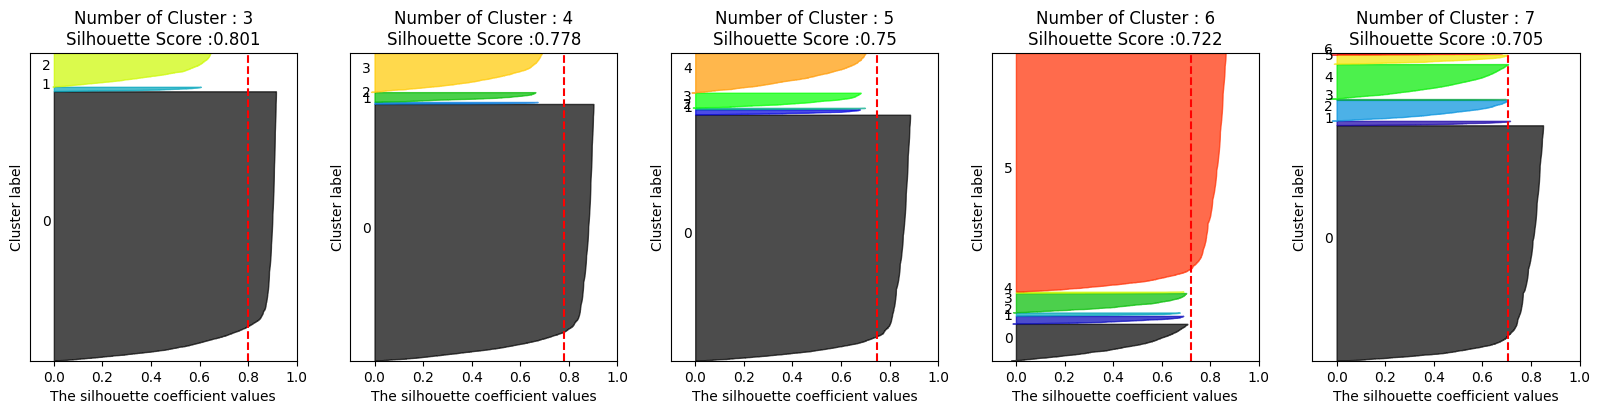

In [33]:
visualize_silhouette([3, 4, 5, 6, 7], X)
# 1에 가까울 수록 근처 군집과 멀리 떨어져 있음

##### Frequency 추가

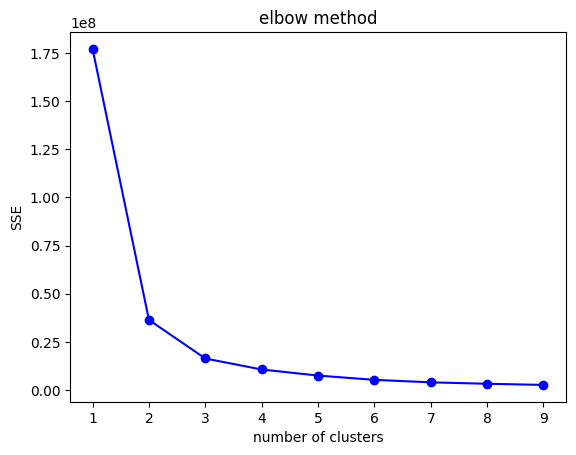

In [43]:
X2 = data[['Frequency',
       'gender_le', 'age_grp_le']]

elbow(X2, 10)

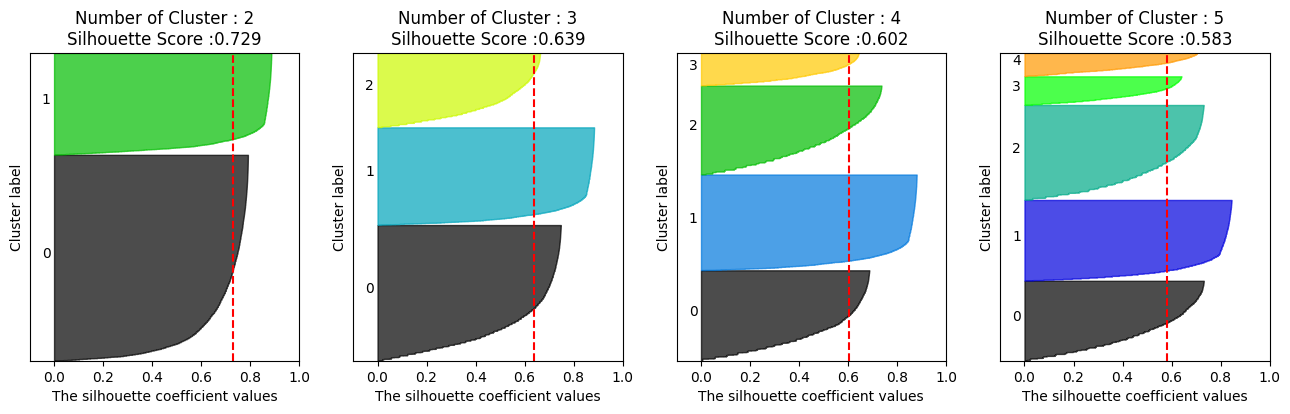

In [44]:
visualize_silhouette([2,3, 4, 5], X2)

##### Recency 추가

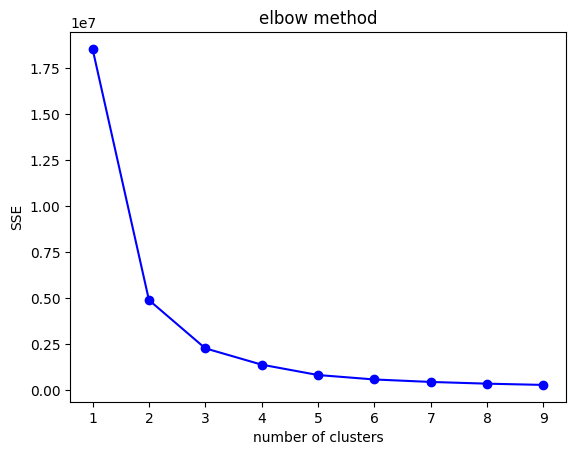

In [45]:
X3 = data[['Recency',
       'gender_le', 'age_grp_le']]

elbow(X3, 10)

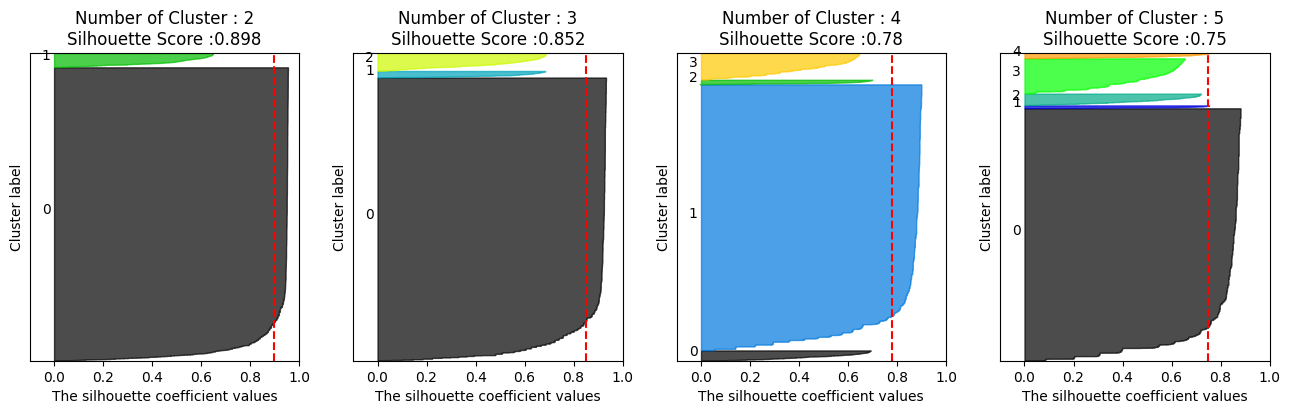

In [47]:
visualize_silhouette([2,3, 4, 5], X3)

##### Monetory 추가

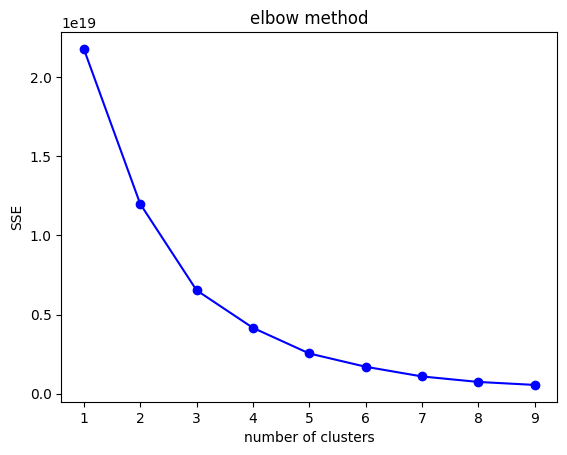

In [48]:
X4 = data[['Monetory',
       'gender_le', 'age_grp_le']]

elbow(X4, 10)

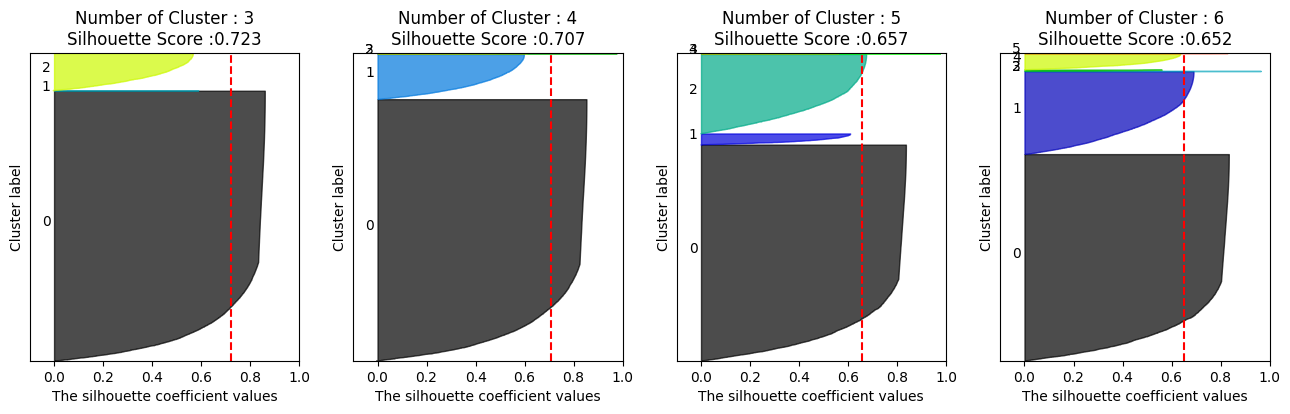

In [49]:
visualize_silhouette([3, 4, 5, 6], X4)

##### 성별제외하고 나이와 Frequency 만으로 군집 분류

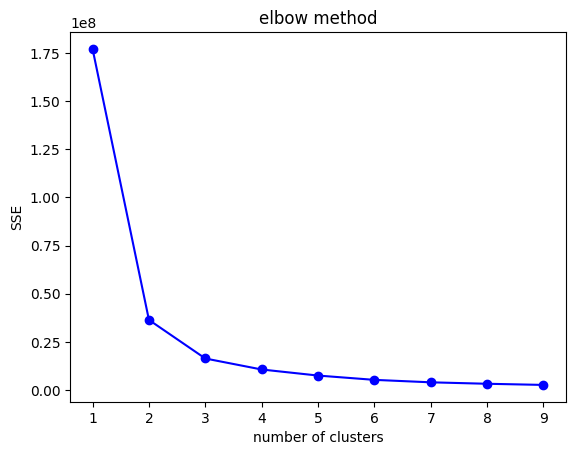

In [61]:
X5 = data[['Frequency', 'age_grp_le']]

elbow(X5, 10)

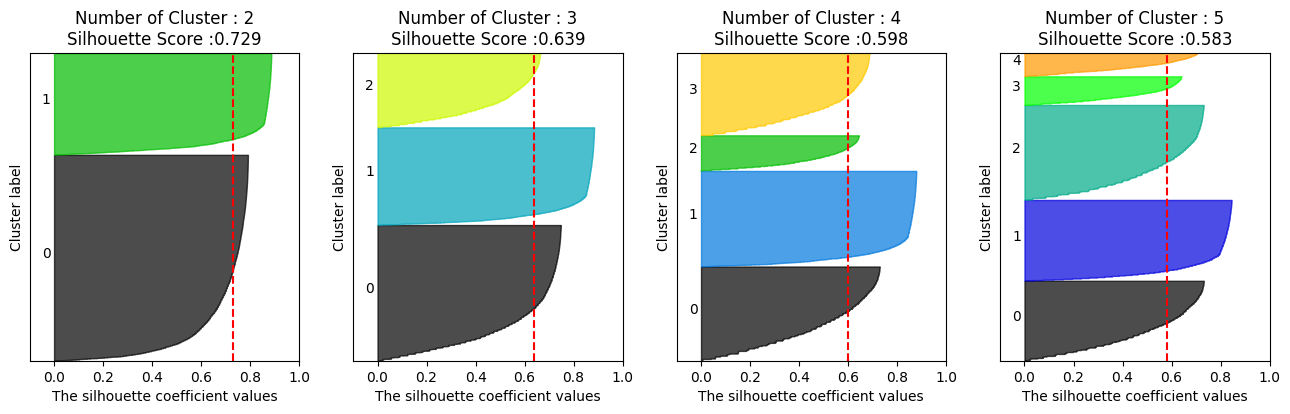

In [63]:
visualize_silhouette([2, 3, 4, 5], X5)

##### 'Recency', 'Frequency', 'Monetory'

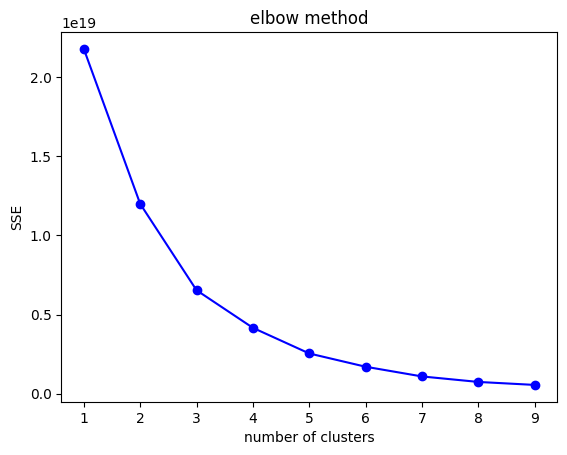

In [65]:
X6 = data[['Recency', 'Frequency', 'Monetory', 'age_grp_le']]

elbow(X6, 10)

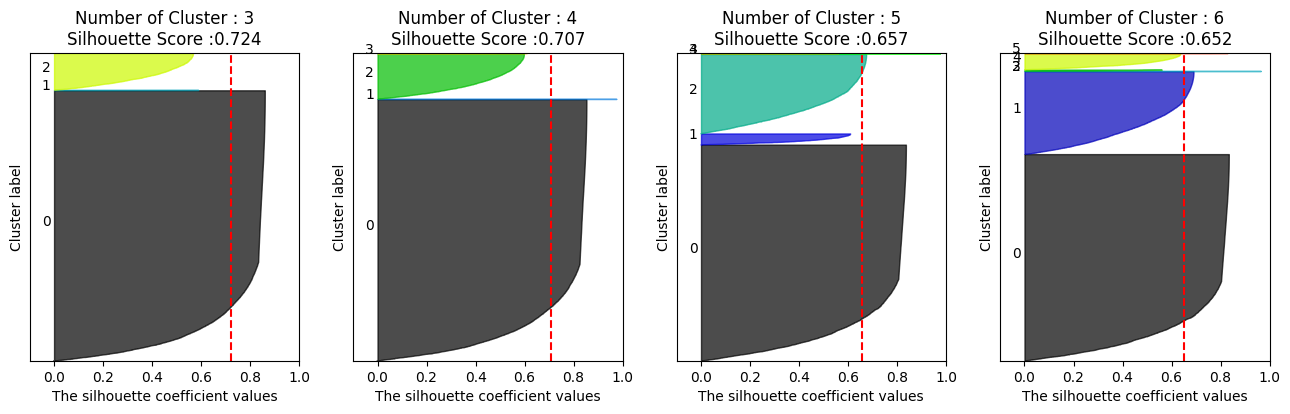

In [66]:
visualize_silhouette([3, 4, 5, 6], X6)

#### 정규화

In [75]:
X7 = minmax(data, ['Recency', 'Frequency', 'Monetory','Purchase_Cycle'])

In [78]:
X7.drop(['cno','gender'], axis=1,inplace=True)

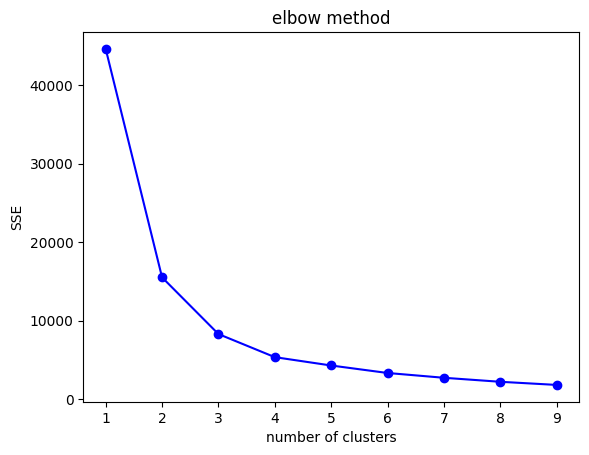

In [79]:
elbow(X7, 10)

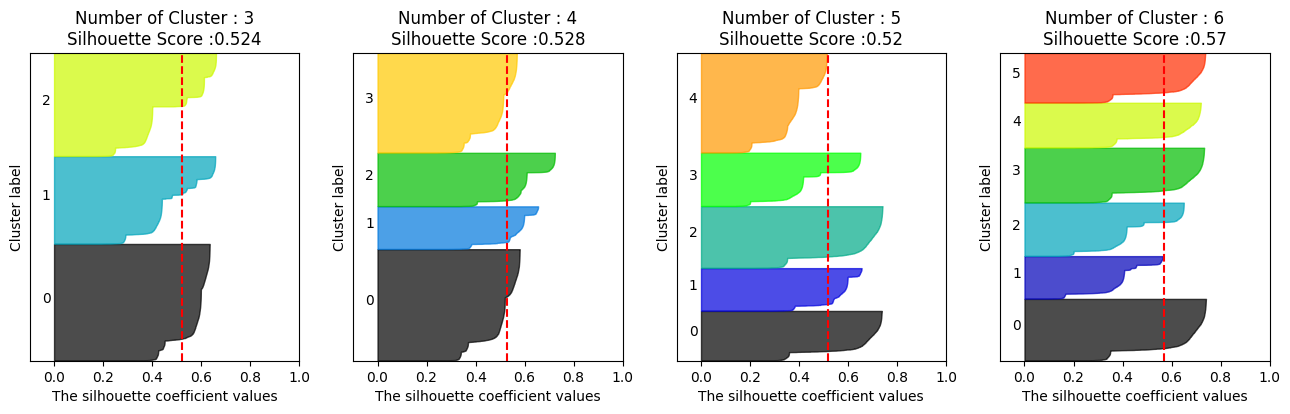

In [81]:
visualize_silhouette([3, 4, 5, 6], X7)

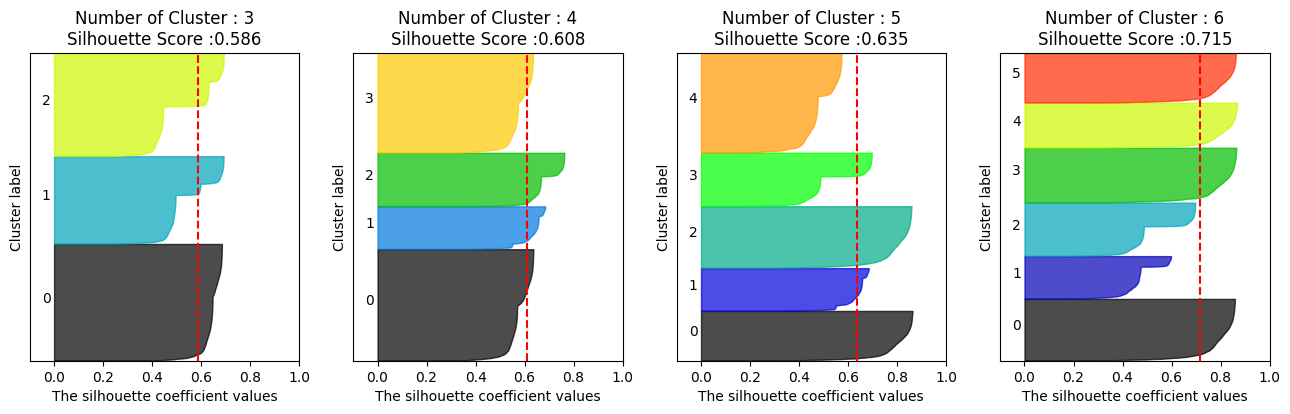

In [84]:
X8 = X7.drop('gender_le',axis=1)
visualize_silhouette([3, 4, 5, 6], X8)

In [100]:
X9.columns

Index(['age_grp_le', 'Frequency_scale', 'Monetory_scale',
       'Purchase_Cycle_scale'],
      dtype='object')

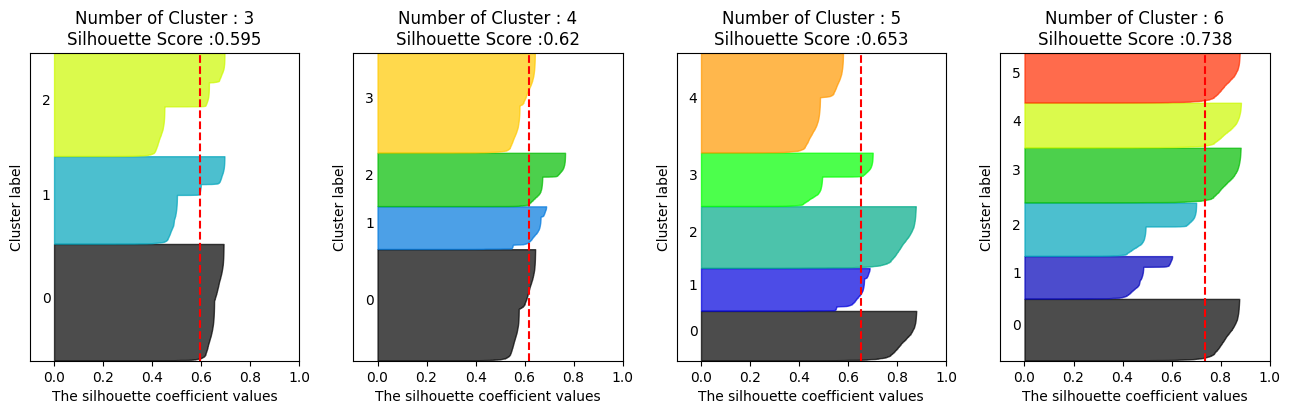

In [86]:
X9 = X8.drop('Recency_scale',axis=1)
visualize_silhouette([3, 4, 5, 6], X9)

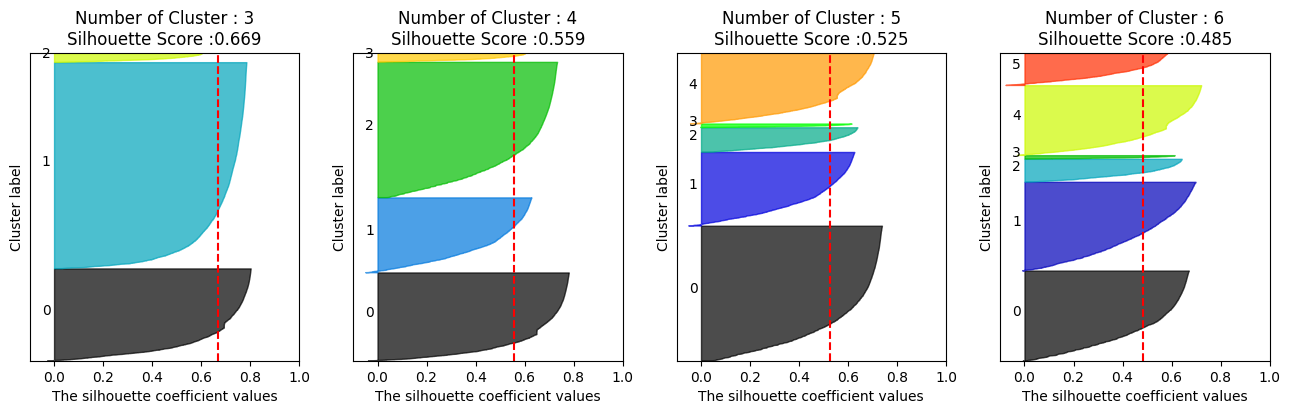

In [99]:
X10 = X9.drop('age_grp_le',axis=1)
visualize_silhouette([3, 4, 5, 6], X10)

In [122]:
X_final, model = cluster_kmeans(X9, 6)

5    2386
4    2117
2    2061
1    1918
0    1733
3    1647
Name: cluster, dtype: int64


### DBSCAN

In [124]:
# X9 가장 군집 잘되었다고 판단
X9.columns # cluster 6

Index(['age_grp_le', 'Frequency_scale', 'Monetory_scale',
       'Purchase_Cycle_scale', 'cluster'],
      dtype='object')

In [117]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [118]:
epsilon = 0.3 # R와 역할, 반지름 지정
minimumSamples = 4 # 최소 4개 요소
db = DBSCAN(eps=epsilon, min_samples=minimumSamples).fit(X9)
labels = db.labels_

In [119]:
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

In [121]:
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print('n_clusters_->', n_clusters_)
print('noise count->', n_noise)

n_clusters_-> 10
noise count-> 7


In [127]:
y = X_final['cluster']

In [128]:
# Kmeans와 평가
print('Homogeneity-> %0.3f' % metrics.homogeneity_score(y, labels))
# 동질성
print("Completeness: %0.3f" % metrics.completeness_score(y, labels))
# 완전성

Homogeneity-> 1.000
Completeness: 0.880


#### 그래프 그려보기


In [166]:
from sklearn.decomposition import PCA
data_pca = X9.copy()
#객체
pca = PCA(n_components=3)
#적용
pca.fit(data_pca)
x_pca = pca.transform(data_pca)
x_pca

array([[-3.41168044, -0.28171405,  0.12214808],
       [-3.41167229, -0.28171138,  0.12035522],
       [-3.41110937, -0.28172019,  0.02344349],
       ...,
       [ 4.56450848,  0.90512427, -0.16217733],
       [ 0.98076241, -1.13323258, -0.23715862],
       [ 3.60131049,  0.63634281, -0.16821382]])

In [167]:
#x_pca를 보기 쉽게 데이터프레임으로 만들기
pca_df = pd.DataFrame(x_pca)
pca_df['cluster'] = X_final['cluster']
pca_df.head()

,0,1,2,cluster
0,-3.411680,-0.281714,0.122148,2
1,-3.411672,-0.281711,0.120355,2
2,-3.411109,-0.281720,0.023443,2
3,-3.410365,-0.281731,-0.106674,2
4,-3.410774,-0.281722,-0.035127,2


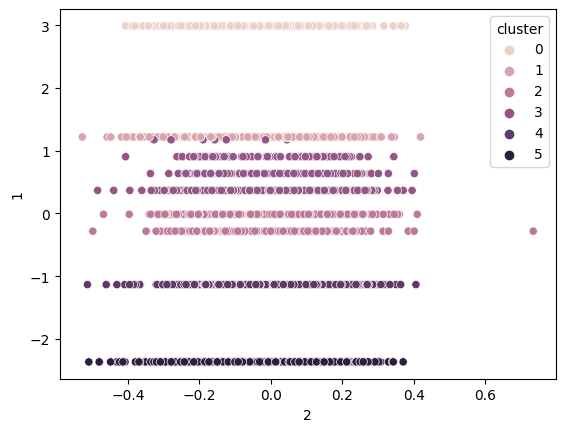

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
axs = plt.subplots()
axs = sns.scatterplot(x=2, y=1, hue='cluster', data=pca_df)

### Tree 그려서 확인

In [196]:
X9.columns

Index(['age_grp_le', 'Frequency_scale', 'Monetory_scale',
       'Purchase_Cycle_scale', 'cluster', 'cno'],
      dtype='object')

In [194]:
# X2.to_csv('./fre_cluster.csv')
# X9.to_csv('./age_cluster.csv')

In [186]:
X_final.to_csv('./age_cluster.csv')

Index(['age_grp_le', 'Frequency_scale', 'Monetory_scale',
       'Purchase_Cycle_scale', 'cluster'],
      dtype='object')

===============max_depth의 제약이 없는 경우의 Decision Tree 시각화==================


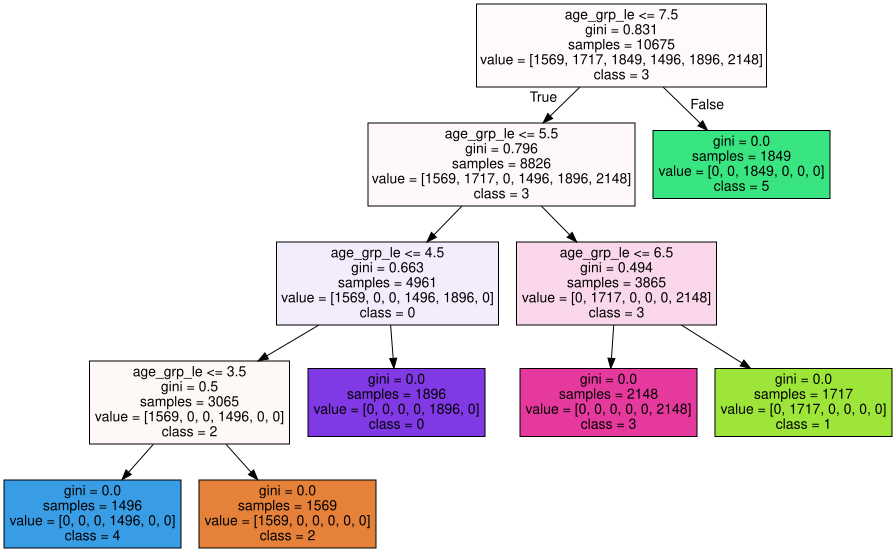

In [178]:
X_tree = X9.drop('cluster',axis=1)
Y = X_final[['cluster']]
decision_viz(X_tree, Y)

In [179]:
# 두번쨰로 괜찮다고 생각되는 X2 데이터 확인
X2.columns

Index(['Frequency', 'gender_le', 'age_grp_le'], dtype='object')

In [184]:
X2_Final, model2 = cluster_kmeans(X2, 3)

1    5234
0    3765
2    2863
Name: cluster, dtype: int64


===============max_depth의 제약이 없는 경우의 Decision Tree 시각화==================


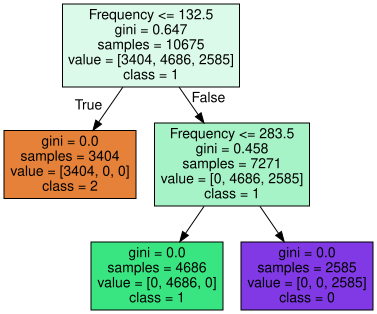

In [185]:
X2_tree = X2.copy()
Y2 = X2_Final[['cluster']]
decision_viz(X2_tree, Y2)

In [197]:
from sklearn.decomposition import PCA
fre_pca = X2_tree.copy()
#객체
pca = PCA(n_components=2)
#적용
pca.fit(fre_pca)
x_pca = pca.transform(fre_pca)
x_pca


array([[ 128.0441023 ,   -3.21244206],
       [ 125.04415286,   -3.21584868],
       [  33.04006725,   -3.32382469],
       ...,
       [-192.97097248,    4.41789408],
       [-189.96644449,    0.42131565],
       [-181.97001323,    3.43038878]])

In [198]:
#x_pca를 보기 쉽게 데이터프레임으로 만들기
pca_df = pd.DataFrame(x_pca)
pca_df['cluster'] = X2['cluster']
pca_df.head()


,0,1,cluster
0,128.044102,-3.212442,2
1,125.044153,-3.215849,2
2,33.040067,-3.323825,1
3,-90.963590,-3.464363,0
4,-23.958972,-3.388551,1


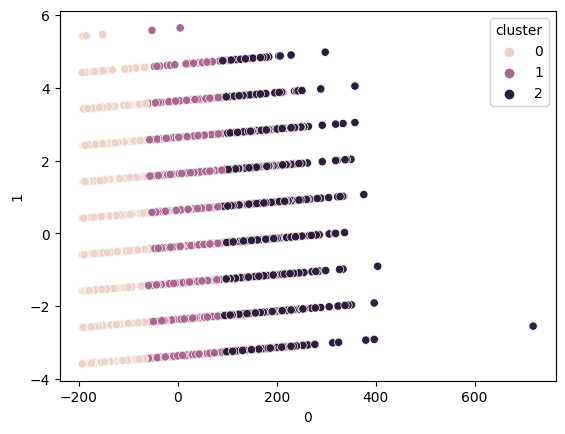

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns
axs = plt.subplots()
axs = sns.scatterplot(x=0, y=1, hue='cluster', data=pca_df)

### 사용자함수

#### 인코딩

In [11]:
# 원핫인코딩
def dum(cust1,coulumn):
  data = pd.get_dummies(cust1[[f'{coulumn}']])
  X_data = pd.concat([cust1,data],axis=1).drop([f'{coulumn}'],axis=1)
  return X_data

In [24]:
def label_at(X_data, li):
  # 라벨인코딩
  from sklearn.preprocessing import LabelEncoder

  for i in li:
    encoder = LabelEncoder()
    X_train = list(X_data[f'{i}'].unique())

    # X_train데이터를 이용 피팅하고 라벨숫자로 변환한다
    encoder.fit(X_train)
    X_encoded = encoder.fit_transform(X_data[f'{i}'])
    X_data[f'{i}_le'] = list(X_encoded)
    X_data = X_data.drop([f'{i}'], axis=1)
    return X_data

In [23]:
# 정규화
def minmax(X_data, li):
  from sklearn.preprocessing import MinMaxScaler

  # 두 가지 feature를 대상
  for i in li:
    data = X_data[[i]]
    scaler = MinMaxScaler()
    data_scale = scaler.fit_transform(data)
    X_data[f'{i}_scale'] = data_scale
    X_data.drop([f'{i}'], axis = 1, inplace=True)
    return X_data

#### 군집확인

In [14]:
def elbow(data, length):
    from sklearn.cluster import KMeans
    import matplotlib.pyplot as plt
    sse = [] # sum of squre error 오차제곱합
    for i in range(1, length):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        # SSE 값 저장
        sse.append(kmeans.inertia_)
    plt.plot(range(1, length), sse, 'bo-')
    plt.title("elbow method")
    plt.xlabel("number of clusters")
    plt.ylabel("SSE")
    plt.show()

In [15]:
# 실루엣 기법
def visualize_silhouette(cluster_lists, X_features): 

    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")


In [17]:
# 최종군집
def cluster_kmeans(X_data, k):
  from sklearn.cluster import KMeans
  import matplotlib.pyplot as plt
  k = k
  # 그룹 수, random_state 설정
  model = KMeans(n_clusters = k, random_state = 10)
  # 정규화된 데이터에 학습
  model.fit(X_data)
  # 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
  X_data['cluster'] = model.fit_predict(X_data)
  print(X_data['cluster'].value_counts())
  return X_data, model

#### 군집 내용

In [174]:
# DecicionTreeClassifier 생성
def decision_viz(X, Y):
  from sklearn.tree import DecisionTreeClassifier
  from sklearn.model_selection import train_test_split

  dt_clf = DecisionTreeClassifier(random_state=156)

  X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.1, random_state=11)

  # DecisionTreeClassifier 학습
  dt_clf.fit(X_train, y_train)

  from sklearn.tree import export_graphviz

  # export_graphviz( )의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성함
  export_graphviz(dt_clf, out_file="tree.dot", class_names = [str(i) for i in list(Y['cluster'].unique())], 
                            feature_names = X.columns, impurity=True, filled=True)
  
  print('===============max_depth의 제약이 없는 경우의 Decision Tree 시각화==================')
  import graphviz
  # 위에서 생성된 tree.dot 파일을 Graphiviz 가 읽어서 시각화
  with open("tree.dot") as f:
      dot_graph = f.read()
  return graphviz.Source(dot_graph)
